# NDVI over Southeast Michigan from Sentinel-2

**Scientific question:** *How has vegetation health changed across selected
areas of Southeast Michigan over time, based on Sentinel-2 satellite
observations?*

This notebook answers a single-scene slice of that question interactively,
using **the same science package the platform runs in production**
(`packages/earth_observation`): the same STAC discovery, the same
deterministic scene selection, the same SCL mask policy, reflectance-offset
handling, and NDVI computation. Nothing here is a reimplementation — see
`docs/scientific-methodology.md` for the full specification.

Requirements: network access (Planetary Computer STAC + assets) and the
workspace environment (`uv sync` from the repository root).

> Contains modified Copernicus Sentinel data, processed by ESA, accessed via
> the Microsoft Planetary Computer.

## Parameters

Edit these and re-run top to bottom. The defaults reproduce the
**Southeast Michigan Demonstration Region** (Pontiac / Auburn Hills /
Rochester Hills, Oakland County, ~137 km²) for the 2024 growing season.

In [1]:
# Parameters ------------------------------------------------------------------
from pathlib import Path

BBOX = (-83.30, 42.55, -83.15, 42.65)  # (min_lon, min_lat, max_lon, max_lat), WGS84
START_DATE = "2024-06-01"
END_DATE = "2024-09-30"
MAX_CLOUD_COVER_PCT = 20.0
SCENE_LIMIT = 3
OUTPUT_DIR = Path("./outputs")  # gitignored; artifacts land here

## 1. Discover candidate scenes (STAC)

`search_scenes` queries the Planetary Computer STAC API (collection
`sentinel-2-l2a`) with the bounding box, inclusive date interval, and an
`eo:cloud_cover` filter, then annotates each candidate with the percent of
the AOI its footprint covers. Candidates carry **original, unsigned** asset
hrefs — signing happens only at read time and signed URLs are never stored.

In [2]:
import pandas as pd

from earth_observation.stac import search_scenes
from earth_observation.types import ProcessingConfig

config = ProcessingConfig()  # production defaults: mask policy, thresholds, display range
candidates = search_scenes(config, BBOX, START_DATE, END_DATE, MAX_CLOUD_COVER_PCT)

candidates_df = pd.DataFrame(
    [
        {
            "item_id": c.item_id,
            "observed_at": c.observed_at,
            "cloud_cover_pct": c.cloud_cover_pct,
            "aoi_overlap_pct": c.aoi_overlap_pct,
            "processing_baseline": c.processing_baseline,
        }
        for c in candidates
    ]
)
print(f"{len(candidates)} candidate scenes between {START_DATE} and {END_DATE}")
candidates_df

25 candidate scenes between 2024-06-01 and 2024-09-30


,item_id,observed_at,cloud_cover_pct,aoi_overlap_pct,processing_baseline
0,S2B_MSIL2A_20240612T161829_R040_T16TGN_2024061...,2024-06-12 16:18:29.024000+00:00,0.833614,50.687718,05.10
1,S2B_MSIL2A_20240612T161829_R040_T17TLH_2024061...,2024-06-12 16:18:29.024000+00:00,0.001377,100.000000,05.10
2,S2B_MSIL2A_20240615T162839_R083_T17TLH_2024061...,2024-06-15 16:28:39.024000+00:00,18.551803,99.984842,05.10
3,S2A_MSIL2A_20240617T161911_R040_T16TGN_2024061...,2024-06-17 16:19:11.024000+00:00,16.713533,50.687718,05.10
4,S2A_MSIL2A_20240627T161901_R040_T16TGN_2024062...,2024-06-27 16:19:01.024000+00:00,17.255439,50.687718,05.10
5,S2A_MSIL2A_20240707T161901_R040_T16TGN_2024070...,2024-07-07 16:19:01.024000+00:00,18.189141,50.687718,05.10
6,S2B_MSIL2A_20240715T162839_R083_T16TGN_2024071...,2024-07-15 16:28:39.024000+00:00,15.430062,50.687718,05.10
7,S2A_MSIL2A_20240727T161831_R040_T16TGN_2024072...,2024-07-27 16:18:31.024000+00:00,0.102048,50.687719,05.11
8,S2A_MSIL2A_20240727T161831_R040_T17TLH_2024072...,2024-07-27 16:18:31.024000+00:00,0.423235,100.000000,05.11
9,S2A_MSIL2A_20240809T162901_R083_T16TGN_2024080...,2024-08-09 16:29:01.024000+00:00,9.519862,50.687718,05.11


## 2. Group granules into acquisitions, then select

One Sentinel-2 acquisition is published as **one STAC item per MGRS tile**, so
an AOI that crosses a tile boundary matches several items for the *same*
observation instant. `group_acquisitions` merges them, and AOI coverage is
computed from the **union** of their footprints.

`select_acquisitions` then applies the documented algorithm
(`temporal-stratified-lowest-cloud` v2.0.0): drop acquisitions whose granules
together cover less than `min_aoi_coverage_pct` (99%) of the AOI, drop those
above the cloud threshold, then — if more remain than the limit — split the
date range into equal time buckets and take the lowest
`(cloud_cover, observed_at, acquisition_key)` per bucket. Every exclusion is
recorded with a reason. Identical inputs always produce identical output.

In [ ]:
from datetime import datetime, timezone

from shapely.geometry import box, mapping

from earth_observation.acquisition import group_acquisitions
from earth_observation.selection import select_acquisitions

aoi_geojson = mapping(box(*BBOX))
acquisitions = group_acquisitions(candidates, aoi_geojson)

multi = [a for a in acquisitions if a.granule_count > 1]
print(f"{len(candidates)} granules -> {len(acquisitions)} acquisitions "
      f"({len(multi)} span more than one granule)")

selection = select_acquisitions(
    acquisitions,
    scene_limit=SCENE_LIMIT,
    max_cloud_cover_pct=MAX_CLOUD_COVER_PCT,
    min_aoi_coverage_pct=config.min_aoi_coverage_pct,
    range_start=datetime.fromisoformat(START_DATE).replace(tzinfo=timezone.utc),
    range_end=datetime.fromisoformat(END_DATE).replace(tzinfo=timezone.utc),
)

print(f"\nalgorithm: {selection.algorithm} v{selection.algorithm_version}")
print(f"selected {len(selection.selected)} of {len(acquisitions)} acquisitions:")
for a in selection.selected:
    print(f"  {a.observed_at:%Y-%m-%d}  cloud={a.cloud_cover_pct:.2f}%  "
          f"coverage={a.aoi_coverage_pct:.1f}%  granules={a.granule_count} {a.tile_ids}")
print(f"\nexcluded {len(selection.excluded)} (first 5):")
for e in selection.excluded[:5]:
    print(f"  {e.acquisition.observed_at:%Y-%m-%d}  reason={e.reason}  "
          f"coverage={e.acquisition.aoi_coverage_pct:.1f}%")

## 3. The canonical grid, then process one acquisition

Every analysis derives **one** grid from the AOI, and every observation is
reprojected onto it. That is what makes dates comparable: identical CRS,
transform, size and AOI mask regardless of which granules supplied the pixels.
Without it, an AOI crossing a tile boundary yields rasters of different sizes
covering different ground — the defect documented in
`docs/audit-2026-08-03-spatial-comparability.md`.

`process_acquisition` then runs the production pipeline: it **signs asset URLs
automatically** immediately before access, performs windowed range reads of
only the grid window (full scenes are never downloaded), **mosaics every
contributing granule** onto the canonical grid (bilinear for the spectral
bands, nearest for the categorical SCL), converts digital numbers to
reflectance with baseline-aware scaling (the additive offset for baseline
>= 04.00 does **not** cancel in the NDVI ratio), masks contaminated pixels,
computes NDVI in float64, and writes a validated float32 COG plus previews and
a summary JSON under `OUTPUT_DIR`.

In [ ]:
from earth_observation.grid import CanonicalGrid
from earth_observation.processing import process_acquisition

grid = CanonicalGrid.from_aoi(aoi_geojson, resolution_m=config.grid_resolution_m)
print(f"canonical grid: {grid.crs}  {grid.width}x{grid.height} px "
      f"@ {grid.resolution[0]} m")
print(f"signature:      {grid.signature()}")
print(f"AOI pixels:     {grid.aoi_pixel_count():,}\n")

acquisition = selection.selected[0]
result = process_acquisition(acquisition, grid, config, OUTPUT_DIR)

print(f"usable={result.usable}  processing_seconds={result.processing_seconds}")
if not result.usable:
    print(f"unusable_reason={result.unusable_reason}")
print(f"contributing granules: {result.acquisition.contributing_item_ids}")
print(f"band_scaling={result.scaling}")
for w in result.warnings:
    print(f"warning: {w}")

## 4. Display: NDVI and true color

The analytical NDVI COG (left) is rendered with the platform's display range
(−0.2 to 0.9). That range is a *rendering* choice — the COG itself retains
the full computed values, including negative NDVI over water. The right panel
is the source-provided true-color (TCI) preview for visual context.

Matplotlib is building the font cache; this may take a moment.


/var/folders/v6/2q1fr8f11v5bp92tz2gc3wd00000gn/T/ipykernel_82128/2314205324.py:11: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ndvi = src.read(1)


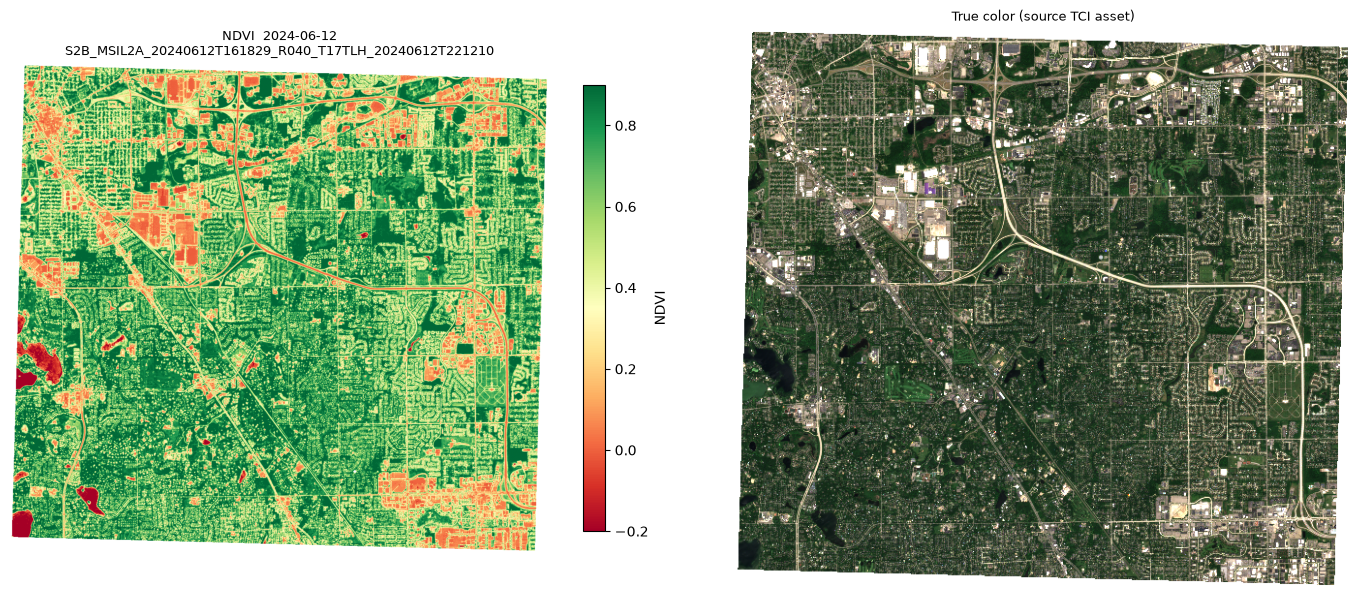

In [5]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import rasterio

assert result.usable and result.outputs is not None, (
    f"Scene not usable ({result.unusable_reason}); pick another from selection.selected"
)

with rasterio.open(result.outputs.ndvi_cog) as src:
    ndvi = src.read(1)
    nodata = src.nodata

ndvi = np.where(ndvi == nodata, np.nan, ndvi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
im = ax1.imshow(ndvi, cmap="RdYlGn", vmin=config.ndvi_display_min, vmax=config.ndvi_display_max)
ax1.set_title(f"NDVI  {scene.observed_at:%Y-%m-%d}\n{scene.item_id}", fontsize=9)
ax1.set_axis_off()
fig.colorbar(im, ax=ax1, shrink=0.8, label="NDVI")

if result.outputs.true_color_preview:
    ax2.imshow(mpimg.imread(result.outputs.true_color_preview))
    ax2.set_title("True color (source TCI asset)", fontsize=9)
else:
    ax2.text(0.5, 0.5, "no true-color asset for this scene", ha="center", va="center")
ax2.set_axis_off()
fig.tight_layout()
plt.show()

## 5. Per-observation statistics and coverage

Statistics are computed over the **canonical AOI mask** — never over whatever
the source granules happened to cover — so every date measures the same
ground. The coverage breakdown accounts for every AOI pixel exactly once, so a
low valid-pixel percentage is always attributable to a specific cause.

In [ ]:
assert result.stats is not None
assert result.coverage is not None

stats = pd.Series(result.stats.model_dump(), name="value").to_frame()
coverage = pd.Series(
    {k: v for k, v in result.coverage.model_dump().items()
     if not isinstance(v, list)},
    name="value",
).to_frame()

print("NDVI statistics (valid pixels only):")
display(stats)
print("Coverage accounting (every AOI pixel classified once):")
display(coverage)

assert result.stats.aoi_pixel_count == grid.aoi_pixel_count(), (
    "statistics must be computed over the canonical AOI mask"
)

## 6. Provenance: the acquisition summary

Every processed acquisition writes a summary JSON recording **every
contributing STAC item and tile**, the observation time, processing baselines,
the exact band scaling applied (and where it came from), the SCL mask policy
in force, the canonical grid, the coverage breakdown, and the **unsigned**
source asset hrefs. In the full platform this feeds a schema-validated
analysis-level provenance document (`docs/data-provenance.md`).

In [7]:
import json

summary = json.loads(Path(result.outputs.scene_summary).read_text())
print(json.dumps(summary, indent=2, sort_keys=True))

{
  "band_scaling": {
    "offset": -0.1,
    "scale": 0.0001,
    "source": "baseline_heuristic"
  },
  "collection": "sentinel-2-l2a",
  "instruments": [
    "msi"
  ],
  "item_id": "S2B_MSIL2A_20240612T161829_R040_T17TLH_20240612T221210",
  "mask_policy_scl_classes": [
    0,
    1,
    3,
    8,
    9,
    10,
    11
  ],
  "observed_at": "2024-06-12T16:18:29.024000+00:00",
  "platform": "Sentinel-2B",
  "processing_baseline": "05.10",
  "raster": {
    "crs": "EPSG:32617",
    "height": 1152,
    "nodata": -9999.0,
    "resolution": [
      10.0,
      10.0
    ],
    "transform": [
      10.0,
      0.0,
      311120.0,
      0.0,
      -10.0,
      4724560.0
    ],
    "width": 1269
  },
  "source_assets_unsigned": {
    "nir": "https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/17/T/LH/2024/06/12/S2B_MSIL2A_20240612T161829_N0510_R040_T17TLH_20240612T221210.SAFE/GRANULE/L2A_T17TLH_A037961_20240612T162626/IMG_DATA/R10m/T17TLH_20240612T161829_B08_10m.tif",
    "red": "https

## Assumptions and limitations

- **Mask policy.** The default SCL policy masks classes 0, 1, 3, 8, 9, 10,
  11 and retains cast shadows (2), vegetation (4), not-vegetated (5), water
  (6, legitimately negative NDVI), and unclassified (7). Different policies
  give different statistics; the policy used is recorded in the summary
  above. Rationale per class: `docs/scientific-methodology.md`.
- **Reflectance offset.** Scenes at processing baseline >= 04.00 are
  converted with `reflectance = DN * 1e-4 - 0.1`. NDVI is a ratio, so the
  multiplicative scale cancels but this additive offset does not — skipping
  it would bias NDVI and create spurious change across the 2022 baseline
  boundary.
- **No interpolation.** The platform reports statistics for actual
  observation dates only. Gaps (clouds, revisit) remain gaps.
- **Interpretation.** An NDVI change is an observed spectral change on
  specific dates. It does not, by itself, establish drought, fire damage,
  climate trends, or crop failure. Read `docs/limitations.md` before drawing
  conclusions.

## From one scene to the platform

This notebook processed one scene by hand. The platform automates the rest:
an API validates AOIs and date ranges, a queue-driven worker (scaling to
zero between jobs) runs this exact pipeline for every selected scene,
excludes scenes with under 10% valid pixels from the series, writes a
time-series CSV of actual observation dates, uploads artifacts to private
blob storage, and emits a schema-validated provenance document with
checksums for every output — making each result auditable and reproducible.
See `docs/architecture.md` for the system design and
`docs/data-provenance.md` for the reproduction walkthrough.